# Avance 3 — Evaluación de Similitud y Equivalencia de Cláusulas (REINSURE.AI)



Equipo: Avance3_#Equipo1


Integrantes:

- Alejandra Berenice Vega López - a01795415@tec.mx

- Paul Andrés Yungán Pinduisaca - a01795702@tec.mx

- Jonathan Ardash Hernández Cruz - a01795404@tec.mx


En esta etapa del proyecto REINSURE.AI se implementa un análisis automatizado para comparar las pre-notas de cobertura y los soportes contractuales de reaseguro. El objetivo principal es evaluar la coherencia entre ambos documentos mediante métricas de similitud semántica y modelos de lenguaje (LLMs) integrados a través de la API de OpenAI.

Este avance corresponde a la fase de validación de consistencia documental, donde se busca detectar discrepancias, evaluar la equivalencia de las cláusulas y visualizar los resultados de forma interpretativa. Con ello, se sientan las bases para el desarrollo de un sistema inteligente de control de calidad contractual que asista al área de Reaseguros en la revisión de documentos técnicos y legales.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Carga y exploración de datos

En este paso se cargó el dataset `reinsurance_data_thb_100.csv`, compuesto por registros  que representan tanto pre-notas de cobertura como soportes.  

El propósito de esta fase es validar la estructura de los datos, revisar tipos de variables y preparar el conjunto para su división entre documentos comparables.

In [ ]:
import pandas as pd

# Se carga el dataset
df = pd.read_csv('reinsurance_data_thb_100.csv')
display(df.head())
display(df.info())

,Folio,record_type,tipo,ramo,reinsurer,participation,reasegurado,asegurado,direccion,periodo_inicio,...,prima_neta,soporte,base_cobertura,territorialidad,jurisdiccion,dias_pago,anexos_clausulas,texto_clausulas,panel_participantes,moneda
0,NC/000001/2016/2017,Pre-nota de Cobertura,Reaseguro Facultativo,Transportes,"Mercury, Pisces",100,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,4003402,100,Claims Made,México,Leyes mexicanas,26,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
1,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Mercury,55,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,2201871,55,Claims Made,México,Leyes mexicanas,36,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
2,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Pisces,45,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,1801531,45,Claims Made,México,Leyes mexicanas,54,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
3,NC/000002/2024/2025,Pre-nota de Cobertura,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,30,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN
4,NC/000002/2024/2025,Soporte,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,54,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Folio                  330 non-null    object
 1   record_type            330 non-null    object
 2   tipo                   330 non-null    object
 3   ramo                   330 non-null    object
 4   reinsurer              330 non-null    object
 5   participation          330 non-null    int64 
 6   reasegurado            330 non-null    object
 7   asegurado              330 non-null    object
 8   direccion              330 non-null    object
 9   periodo_inicio         330 non-null    object
 10  periodo_fin            330 non-null    object
 11  actividad              330 non-null    object
 12  estimado_ingresos      330 non-null    int64 
 13  interes_asegurable     330 non-null    object
 14  limite_max_res         330 non-null    int64 
 15  riesgos_cubiertos      

None

## Dividir los datos


Crear dos nuevos dataframes, uno para los registros de tipo 'prenota de cobertura' y otro para los registros de tipo 'soporte', basándose en la columna relevante (que habrá que identificar en los datos).


In [ ]:
df_prenota = df[df['record_type'] == 'Pre-nota de Cobertura']
df_soporte = df[df['record_type'] == 'Soporte']

display(df_prenota.head())
display(df_soporte.head())

,Folio,record_type,tipo,ramo,reinsurer,participation,reasegurado,asegurado,direccion,periodo_inicio,...,prima_neta,soporte,base_cobertura,territorialidad,jurisdiccion,dias_pago,anexos_clausulas,texto_clausulas,panel_participantes,moneda
0,NC/000001/2016/2017,Pre-nota de Cobertura,Reaseguro Facultativo,Transportes,"Mercury, Pisces",100,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,4003402,100,Claims Made,México,Leyes mexicanas,26,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
3,NC/000002/2024/2025,Pre-nota de Cobertura,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,30,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN
5,NC/000003/2018/2019,Pre-nota de Cobertura,Reaseguro Facultativo,Ramos Técnicos,"Saturn, UrsaMajor, Andromeda",100,Aseguradora del Norte,"Transporte Global, S.A.",Ciudad de México,26/01/18 0:00,...,3639704,100,Claims Made,México,Leyes mexicanas,57,"NMA 2737, NMA 2705, NMA 464, Endorsement 9101,...","Cooperacion de reclamos, Acción Razonable; Exc...","Saturn 14%, UrsaMajor 49%, Andromeda 37%",MXN
9,NC/000004/2017/2018,Pre-nota de Cobertura,Reaseguro Facultativo,Transportes,Jupiter,100,"Seguros Central, S.A.","Servicios Integrales del Valle, S.A. de C.V.","Monterrey, Nuevo León",14/11/17 0:00,...,7952574,100,Claims Made,México,Leyes mexicanas,31,"NMA 2737, NMA 2738, Endorsement 5678, NMA 3001...","Cooperacion de reclamos, Control de Pérdidas; ...",Jupiter 100%,MXN
11,NC/000005/2024/2025,Pre-nota de Cobertura,Reaseguro Facultativo,Responsabilidad Ambiental,"Orion, Taurus, Pegasus, Scorpius, Uranus, Jupi...",100,Grupo Financiero Unión,"Transporte Global, S.A.","San Luis Potosí, San Luis Potosí",07/07/24 0:00,...,3474754,100,Claims Made,México,Leyes mexicanas,34,"NMA 2737, NMA 2738, Endorsement 1234, LMA 3092...","Cooperacion de reclamos, Control de Pérdidas; ...","Orion 2%, Taurus 5%, Pegasus 14%, Scorpius 11%...",USD


,Folio,record_type,tipo,ramo,reinsurer,participation,reasegurado,asegurado,direccion,periodo_inicio,...,prima_neta,soporte,base_cobertura,territorialidad,jurisdiccion,dias_pago,anexos_clausulas,texto_clausulas,panel_participantes,moneda
1,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Mercury,55,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,2201871,55,Claims Made,México,Leyes mexicanas,36,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
2,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Pisces,45,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,1801531,45,Claims Made,México,Leyes mexicanas,54,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
4,NC/000002/2024/2025,Soporte,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,54,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN
6,NC/000003/2018/2019,Soporte,Reaseguro Facultativo,Ramos Técnicos,Saturn,14,Aseguradora del Norte,"Transporte Global, S.A.",Ciudad de México,26/01/18 0:00,...,509559,14,Claims Made,México,Leyes mexicanas,47,"NMA 2737, NMA 2705, NMA 464, Endorsement 9101,...","Cooperacion de reclamos, Acción Razonable; Exc...","Saturn 14%, UrsaMajor 49%, Andromeda 37%",MXN
7,NC/000003/2018/2019,Soporte,Reaseguro Facultativo,Ramos Técnicos,UrsaMajor,49,Aseguradora del Norte,"Transporte Global, S.A.",Ciudad de México,26/01/18 0:00,...,1783455,49,Claims Made,México,Leyes mexicanas,57,"NMA 2737, NMA 2705, NMA 464, Endorsement 9101,...","Cooperacion de reclamos, Acción Razonable; Exc...","Saturn 14%, UrsaMajor 49%, Andromeda 37%",MXN


## Preparar los datos para la comparación

Seleccionar las variables relevantes de cada dataframe para la comparación y, si es necesario, preprocesar los datos (por ejemplo, manejar valores nulos, formatear cadenas, etc.).


In [ ]:
import numpy as np
import pandas as pd

# Crea df_prenota y df_soporte
df_prenota = df[df['record_type'] == 'Pre-nota de Cobertura']
df_soporte = df[df['record_type'] == 'Soporte']

# Identifica las columnas relevantes
# Se obtienen todas las columnas después de 'record_type'
all_columns = df.columns.tolist()
start_index = all_columns.index('ramo')
relevant_columns = all_columns[start_index:]

# Se excluyen las columnas que claramente no son basadas en texto o adecuadas para comparación de texto
excluded_columns = ['participation', 'estimado_ingresos', 'limite_max_res',
                    'deducible_General', 'deducible_Robo', 'deducible_Terremoto',
                    'deducible_Electricos', 'deducible_Ingresos', 'soporte', 'dias_pago']

relevant_columns = [col for col in relevant_columns if col not in excluded_columns]

print(f"Columnas relevantes para la comparación: {relevant_columns}")


# Se manejan los valores faltantes y asegura el tipo de cadena
# Usa .copy() para evitar SettingWithCopyWarning
df_prenota = df_prenota.copy()
df_soporte = df_soporte.copy()

for col in relevant_columns:
    df_prenota[col] = df_prenota[col].fillna('').astype(str)
    df_soporte[col] = df_soporte[col].fillna('').astype(str)

# Se limpian texto (minúsculas y eliminación de puntuación)
# Usa doble barra invertida para secuencias de escape regex para evitar SyntaxWarning
df_prenota[relevant_columns] = df_prenota[relevant_columns].apply(lambda x: x.str.lower().str.replace('[^\\w\\s]', '', regex=True))
df_soporte[relevant_columns] = df_soporte[relevant_columns].apply(lambda x: x.str.lower().str.replace('[^\\w\\s]', '', regex=True))

# Se crea un dataframe combinado con texto de soporte concatenado para cada Folio
agg_dict = {col: lambda x: ' '.join(x) for col in relevant_columns}
df_soporte_agg = df_soporte.groupby('Folio')[relevant_columns].agg(agg_dict).reset_index()

# Se fusiona por Folio e incluye todas las columnas relevantes de prenota también
df_combined = pd.merge(df_prenota[['Folio'] + relevant_columns], df_soporte_agg, on='Folio', suffixes=('_prenota', '_soporte'))


display(df_combined.head())

Columnas relevantes para la comparación: ['ramo', 'reinsurer', 'reasegurado', 'asegurado', 'direccion', 'periodo_inicio', 'periodo_fin', 'actividad', 'estimado_ingresos ', 'interes_asegurable', 'limite_max_res ', 'riesgos_cubiertos', 'condiciones_reaseguro', 'exclusiones', 'deducible_General ', 'deducible_Robo ', 'deducible_Terremoto ', 'deducible_Electricos ', 'deducible_Ingresos ', 'prima_neta ', 'base_cobertura', 'territorialidad', 'jurisdiccion', 'anexos_clausulas', 'texto_clausulas', 'panel_participantes', 'moneda']


,Folio,ramo_prenota,reinsurer_prenota,reasegurado_prenota,asegurado_prenota,direccion_prenota,periodo_inicio_prenota,periodo_fin_prenota,actividad_prenota,estimado_ingresos _prenota,...,deducible_Electricos _soporte,deducible_Ingresos _soporte,prima_neta _soporte,base_cobertura_soporte,territorialidad_soporte,jurisdiccion_soporte,anexos_clausulas_soporte,texto_clausulas_soporte,panel_participantes_soporte,moneda_soporte
0,NC/000001/2016/2017,transportes,mercury pisces,aseguradora del norte,servicios financieros unión,san luis potosí san luis potosí,141016 000,141017 000,operación de transporte terrestre,13575562,...,93563 93563,46062 46062,2201871 1801531,claims made claims made,méxico méxico,leyes mexicanas leyes mexicanas,nma 2737 endorsement 5678 nma 2962 lma 3092 lm...,cooperacion de reclamos all risks prevención d...,mercury 55 pisces 45 mercury 55 pisces 45,mxn mxn
1,NC/000002/2024/2025,responsabilidad civil,andromeda,aseguradora del norte,tecnologías avanzadas sa,tijuana baja california,230424 000,230425 000,prestación de servicios,89753260,...,69823,56434,4955124,claims made,méxico,leyes mexicanas,nma 2737 lma 3100a endorsement 1234 nma 2800 n...,cooperacion de reclamos limitación de sancione...,andromeda 100,mxn
2,NC/000003/2018/2019,ramos técnicos,saturn ursamajor andromeda,aseguradora del norte,transporte global sa,ciudad de méxico,260118 000,260119 000,ingeniería y construcción,36935572,...,85435 85435 85435,71856 71856 71856,509559 1783455 1346690,claims made claims made claims made,méxico méxico méxico,leyes mexicanas leyes mexicanas leyes mexicanas,nma 2737 nma 2705 nma 464 endorsement 9101 nma...,cooperacion de reclamos acción razonable exclu...,saturn 14 ursamajor 49 andromeda 37 saturn 14 ...,mxn mxn mxn
3,NC/000004/2017/2018,transportes,jupiter,seguros central sa,servicios integrales del valle sa de cv,monterrey nuevo león,141117 000,141118 000,operación de transporte terrestre,52642594,...,21504,35014,7952574,claims made,méxico,leyes mexicanas,nma 2737 nma 2738 endorsement 5678 nma 3001 lm...,cooperacion de reclamos control de pérdidas al...,jupiter 100,mxn
4,NC/000005/2024/2025,responsabilidad ambiental,orion taurus pegasus scorpius uranus jupiter d...,grupo financiero unión,transporte global sa,san luis potosí san luis potosí,070724 000,070725 000,gestión medioambiental,98969689,...,77422 77422 77422 77422 77422 77422 77422 7742...,87839 87839 87839 87839 87839 87839 87839 8783...,69495 173738 486466 382223 104243 104243 27798...,claims made claims made claims made claims mad...,méxico méxico méxico méxico méxico méxico méxi...,leyes mexicanas leyes mexicanas leyes mexicana...,nma 2737 nma 2738 endorsement 1234 lma 3092 lm...,cooperacion de reclamos control de pérdidas ex...,orion 2 taurus 5 pegasus 14 scorpius 11 uranus...,usd usd usd usd usd usd usd usd usd usd usd us...


## Configurar la api de openai

Configurar la clave de API de OpenAI para poder realizar llamadas a la API.


In [ ]:
import openai
import os

openai.api_key = 'sk-proj-fake'

## Comparar variables usando la api de openai

Utilizando la API de OpenAI y el modelo `gpt-4o-mini`, se implementó la función `get_similarity_score()`, que retorna una puntuación entre **0 y 1**, donde:
- 1 representa una coincidencia semántica completa.
- 0 indica ausencia total de similitud.

Se aplicó un enfoque con lógica de reintento y control de errores para evitar interrupciones por límites de tasa.  


In [ ]:
from tenacity import retry, wait_random_exponential, stop_after_attempt
import time
import numpy as np
import re # Se importa el módulo re para expresiones regulares

# Se define la función de cálculo de similitud con lógica de reintento
@retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
def get_similarity_score(text1, text2):
    """Calcula una puntuación de similitud entre dos entradas de texto usando la API de OpenAI."""
    try:
        response = openai.chat.completions.create(
            model="gpt-4o-mini", # Suficiente para generar un Baseline
            messages=[
                {"role": "system", "content": "Eres un asistente útil que compara dos textos y proporciona una puntuación de similitud entre 0 y 1, donde 1 es muy similar y 0 no es similar. Proporciona SOLO la puntuación numérica."},
                {"role": "user", "content": f"Compara los siguientes dos textos y proporciona una puntuación de similitud:\n\nTexto 1: {text1}\n\nTexto 2: {text2}\n\nPuntuación de Similitud:"}
            ],
            max_tokens=10,
            temperature=0
        )
        score_str = response.choices[0].message.content.strip()
        try:
            # Intenta convertir la puntuación a un número flotante
            score = float(score_str)
            # Nos aseguramos de que la puntuación esté dentro del rango 0-1
            score = max(0, min(1, score))
            #print(f"Puntuación obtenida con éxito: {score}") # Se añadió print para éxito
            return score
        except ValueError:
            # Se usa regex para encontrar una puntuación numérica en la respuesta si la conversión directa falla
            match = re.search(r'\d+\.?\d*', score_str)
            if match:
                score = float(match.group(0))
                score = max(0, min(1, score))
                print(f"Advertencia: Puntuación '{score}' extraída de respuesta no numérica de la API: {score_str}")
                return score
            else:
                print(f"Advertencia: No se pudo convertir o extraer la puntuación de la respuesta de la API: {score_str}")
                return np.nan # Devuelve NaN en caso de que no se encuentre una puntuación válida
    except Exception as e:
        print(f"Error durante la llamada a la API de OpenAI: {e}")
        return np.nan # Devuelve NaN en caso de errores de la API

# Se identifican las columnas relevantes (definidas en el paso anterior pero necesarias aquí)
relevant_columns = ['ramo', 'reinsurer', 'reasegurado', 'asegurado', 'direccion', 'periodo_inicio', 'periodo_fin', 'actividad', 'estimado_ingresos ', 'interes_asegurable', 'limite_max_res ', 'riesgos_cubiertos', 'condiciones_reaseguro', 'exclusiones', 'deducible_General ', 'deducible_Robo ', 'deducible_Terremoto ', 'deducible_Electricos ', 'deducible_Ingresos ', 'prima_neta ', 'base_cobertura', 'territorialidad', 'jurisdiccion', 'anexos_clausulas', 'texto_clausulas', 'panel_participantes', 'moneda']


# Se limita a las primeras 5 filas para probar
#df_combined_subset = df_combined.head(5).copy()
# Se calcula los indices de similitud para el dataset completo (Implica un mayor costo por el uso del API de OpenAI)
df_combined_subset = df_combined.copy()


# Se itera y calcula las puntuaciones de similitud
for col in relevant_columns:
    prenota_col = f'{col}_prenota'
    soporte_col = f'{col}_soporte'
    similarity_col = f'similarity_{col}'
    df_combined_subset[similarity_col] = np.nan # Inicializa con NaN

    for index, row in df_combined_subset.iterrows():
        text_prenota = row[prenota_col]
        text_soporte = row[soporte_col]

        #print(f"Procesando Folio: {row['Folio']}, Columna: {col}") # Se añadió print para mostrar el progreso

        # Se calcula la similitud solo si ambos textos no están vacíos
        if text_prenota and text_soporte:
            similarity_score = get_similarity_score(text_prenota, text_soporte)
            df_combined_subset.at[index, similarity_col] = similarity_score
        else:
            df_combined_subset.at[index, similarity_col] = 0 # Asigna 0 de similitud si uno o ambos textos están vacíos
            print(f"Saltando cálculo de similitud debido a texto vacío para Folio: {row['Folio']}, Columna: {col}") # Se añadió print para saltar

        # Añade un pequeño retraso para evitar alcanzar los límites de tasa
        time.sleep(0.1)

display(df_combined_subset.head())

,Folio,ramo_prenota,reinsurer_prenota,reasegurado_prenota,asegurado_prenota,direccion_prenota,periodo_inicio_prenota,periodo_fin_prenota,actividad_prenota,estimado_ingresos _prenota,...,similarity_deducible_Electricos,similarity_deducible_Ingresos,similarity_prima_neta,similarity_base_cobertura,similarity_territorialidad,similarity_jurisdiccion,similarity_anexos_clausulas,similarity_texto_clausulas,similarity_panel_participantes,similarity_moneda
0,NC/000001/2016/2017,transportes,mercury pisces,aseguradora del norte,servicios financieros unión,san luis potosí san luis potosí,141016 000,141017 000,operación de transporte terrestre,13575562,...,0.8,0.5,0.0,0.8,0.5,0.8,0.75,0.85,1.0,0.5
1,NC/000002/2024/2025,responsabilidad civil,andromeda,aseguradora del norte,tecnologías avanzadas sa,tijuana baja california,230424 000,230425 000,prestación de servicios,89753260,...,1.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.0,1.0
2,NC/000003/2018/2019,ramos técnicos,saturn ursamajor andromeda,aseguradora del norte,transporte global sa,ciudad de méxico,260118 000,260119 000,ingeniería y construcción,36935572,...,0.8,0.5,0.0,0.8,0.5,0.8,0.80,1.00,0.8,0.5
3,NC/000004/2017/2018,transportes,jupiter,seguros central sa,servicios integrales del valle sa de cv,monterrey nuevo león,141117 000,141118 000,operación de transporte terrestre,52642594,...,1.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.0,1.0
4,NC/000005/2024/2025,responsabilidad ambiental,orion taurus pegasus scorpius uranus jupiter d...,grupo financiero unión,transporte global sa,san luis potosí san luis potosí,070724 000,070725 000,gestión medioambiental,98969689,...,0.5,0.5,0.0,0.5,0.5,0.9,0.50,1.00,0.9,0.5


## Resultados de similitud promedio

El promedio de similitud por columna muestra una variación significativa entre los distintos campos:

- **Menor similitud:** `prima_neta` (0.41), indicando que los valores monetarios presentan discrepancias notables entre la pre-nota y el soporte.
- **Mayor similitud:** `exclusiones` (0.999) y `reinsurer` (0.9847), lo cual refleja consistencia alta en los campos de identificación y exclusión de riesgos.


In [ ]:
# Se calcula la media del indice de similitud para cada columna
mean_similarity_per_column = df_similarity_subset.mean().sort_values()

print("Average Similarity Score per Column (Lowest First):")
display(mean_similarity_per_column)

# Se obtiene el minimo
overall_min_similarity = df_similarity_subset.min().min()

# Se obtiene la ubicacion de cada uno de los minimos Find
lowest_similarity_locations = df_similarity_subset[df_similarity_subset == overall_min_similarity].stack().index.tolist()

print(f"\nOverall Minimum Similarity Score: {overall_min_similarity}")
print("Location(s) of Overall Minimum Similarity Score (Folio, Column):")
for location in lowest_similarity_locations:
    print(location)

Average Similarity Score per Column (Lowest First):


,0
prima_neta,0.411000
moneda,0.706000
territorialidad,0.715000
deducible_Robo,0.749000
deducible_General,0.754000
deducible_Electricos,0.763000
deducible_Terremoto,0.765000
deducible_Ingresos,0.765000
estimado_ingresos,0.790500
base_cobertura,0.803500



Overall Minimum Similarity Score: 0.0
Location(s) of Overall Minimum Similarity Score (Folio, Column):
('NC/000001/2016/2017', 'prima_neta ')
('NC/000003/2018/2019', 'prima_neta ')
('NC/000005/2024/2025', 'prima_neta ')
('NC/000006/2016/2017', 'prima_neta ')
('NC/000007/2022/2023', 'prima_neta ')
('NC/000009/2017/2018', 'prima_neta ')
('NC/000010/2016/2017', 'prima_neta ')
('NC/000013/2021/2022', 'prima_neta ')
('NC/000014/2018/2019', 'prima_neta ')
('NC/000015/2022/2023', 'prima_neta ')
('NC/000016/2024/2025', 'prima_neta ')
('NC/000018/2016/2017', 'prima_neta ')
('NC/000019/2024/2025', 'prima_neta ')
('NC/000020/2020/2021', 'prima_neta ')
('NC/000022/2023/2024', 'prima_neta ')
('NC/000023/2018/2019', 'prima_neta ')
('NC/000025/2019/2020', 'prima_neta ')
('NC/000028/2023/2024', 'prima_neta ')
('NC/000029/2022/2023', 'prima_neta ')
('NC/000031/2016/2017', 'prima_neta ')
('NC/000033/2023/2024', 'prima_neta ')
('NC/000035/2022/2023', 'prima_neta ')
('NC/000036/2020/2021', 'prima_neta ')

Estos resultados se visualizan en el mapa de calor donde los tonos más oscuros indican menor coincidencia, permitiendo detectar fácilmente los puntos críticos de divergencia documental.

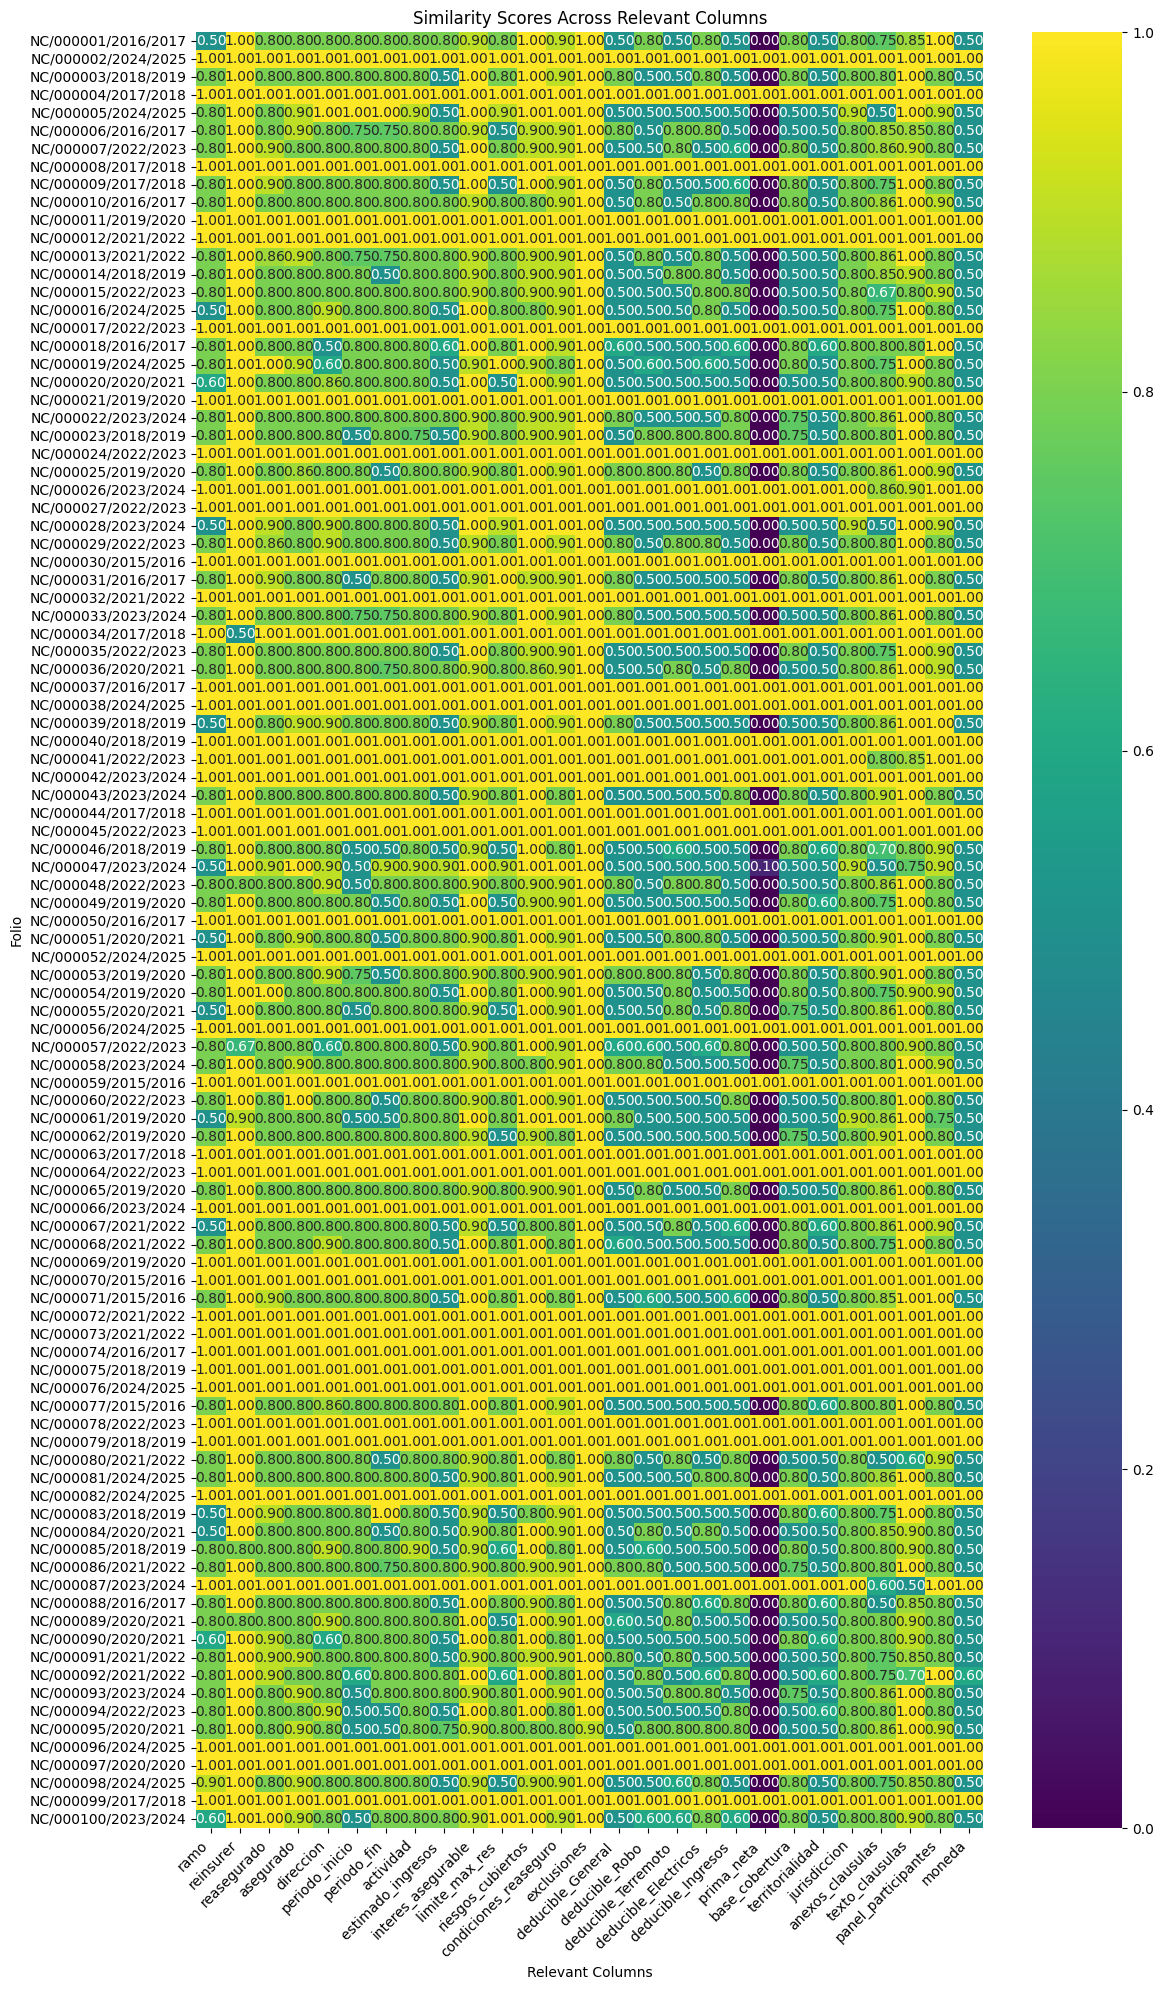

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Se seleccionan solo las columnas con similitud
similarity_columns = [col for col in df_combined_subset.columns if col.startswith('similarity_')]
df_similarity_subset = df_combined_subset[['Folio'] + similarity_columns]

# Se renombra las columnas de similitud para una mejor lectura del grafico
df_similarity_subset.columns = ['Folio'] + [col.replace('similarity_', '') for col in similarity_columns]

# Se asigna folio xomo indice para el mapa de calor Set
df_similarity_subset = df_similarity_subset.set_index('Folio')

# Se crea el mapa de calor
plt.figure(figsize=(12, 20))
sns.heatmap(df_similarity_subset, annot=True, cmap='viridis', fmt=".2f")
plt.title('Similarity Scores Across Relevant Columns')
plt.xlabel('Relevant Columns')
plt.ylabel('Folio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Identificación de casos con baja similitud

Se identificaron múltiples folios con puntuaciones de similitud **igual a 0** en la variable `prima_neta`.  
Este hallazgo sugiere discrepancias numéricas entre las pre-notas y los soportes, ya sea por actualización de montos o errores de registro.

Ejemplo:
- Folio `NC/000001/2016/2017`: Pre-nota = 4,003,402 vs. Soporte = 2,201,871 / 1,801,531  
- Folio `NC/000005/2024/2025`: múltiples valores agregados en el soporte.

Estos casos se marcan como “negocios por revisar”, ya que implican diferencias materiales en la estructura económica del contrato.


In [ ]:
# Se obtiene y despliega el texto original para cada registro con el menor indice de similitud.
print("Negocios por revisar debido a un bajo indice de similitud:")

for folio, column in lowest_similarity_locations:
    original_column = column.replace('similarity_', '') # obtiene el nombre original de la columna
    prenota_col = f'{original_column}_prenota'
    soporte_col = f'{original_column}_soporte'

    # Se encuentra la fila en df_combined_subset con base en el Folio
    record = df_combined_subset[df_combined_subset['Folio'] == folio].iloc[0]

    print(f"\nFolio: {folio}, Column: {original_column}")
    print(f"  Similarity Score: {record[f'similarity_{original_column}']}")
    print(f"  Texto Pre-nota: {record[prenota_col]}")
    print(f"  Texto Soporte: {record[soporte_col]}")
    print("-" * 30)

Negocios por revisar debido a un bajo indice de similitud:

Folio: NC/000001/2016/2017, Column: prima_neta 
  Similarity Score: 0.0
  Texto Pre-nota: 4003402
  Texto Soporte: 2201871 1801531
------------------------------

Folio: NC/000003/2018/2019, Column: prima_neta 
  Similarity Score: 0.0
  Texto Pre-nota: 3639704
  Texto Soporte: 509559 1783455 1346690
------------------------------

Folio: NC/000005/2024/2025, Column: prima_neta 
  Similarity Score: 0.0
  Texto Pre-nota: 3474754
  Texto Soporte: 69495 173738 486466 382223 104243 104243 277980 34748 347475 382223 486466 243233 69495 312728
------------------------------

Folio: NC/000006/2016/2017, Column: prima_neta 
  Similarity Score: 0.0
  Texto Pre-nota: 1008841
  Texto Soporte: 706189 302652
------------------------------

Folio: NC/000007/2022/2023, Column: prima_neta 
  Similarity Score: 0.0
  Texto Pre-nota: 9196526
  Texto Soporte:      2758958 6437568
------------------------------

Folio: NC/000009/2017/2018, Column: 

## Clasificadores de equivalencia semántica

Para avanzar hacia una evaluación cualitativa, se definieron tres niveles de análisis basados en la API de OpenAI:

1. **Clasificador básico:** determina si dos cláusulas son equivalentes de forma *plena*, *parcial* o *nula*.  
   - Ejemplo: cláusulas idénticas en intención y alcance → "plena".
   - Cláusulas con diferencias menores → "parcial".

2. **Clasificador multidimensional:** evalúa similitud por dimensiones específicas (`riesgos`, `límites`, `deducibles`, `condiciones`, `territorio`, `periodo`) y produce un promedio global.  
   - Un caso típico obtuvo un promedio de **0.83**, clasificándose como *parcial* debido a un riesgo adicional en la cláusula B.


In [ ]:
import json

@retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
def get_equivalence_basic(text1, text2):
    """
    Compara dos cláusulas y devuelve una etiqueta de equivalencia
    (plena/parcial/nula) + explicación breve. Respuesta en JSON.
    """
    system_msg = (
        "Eres un analista especializado en contratos de reaseguro. "
        "Compara dos cláusulas de cobertura y devuelve SOLO JSON válido."
    )
    user_msg = f"""
Compara las siguientes dos cláusulas y determina si su equivalencia es 'plena', 'parcial' o 'nula'.

Reglas:
- 'plena': misma intención y alcance (riesgos, límites, deducibles, condiciones, territorio, periodo), con variaciones menores de redacción.
- 'parcial': intención similar, pero con alguna diferencia relevante.
- 'nula': intención distinta o contradictoria (una incluye un riesgo y la otra lo excluye).

Cláusula A:
{text1}

Cláusula B:
{text2}

Devuelve SOLO este JSON:
{{
  "equivalencia": "plena" | "parcial" | "nula",
  "explicacion": "<= 2 oraciones, lenguaje claro>"
}}
""".strip()

    try:
        response = openai.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_msg},
                {"role": "user", "content": user_msg}
            ],
            max_tokens=300,
            temperature=0
        )
        payload = response.choices[0].message.content.strip()
        data = json.loads(payload)
        # Validación mínima
        assert data.get("equivalencia") in {"plena", "parcial", "nula"}
        return data
    except Exception as e:
        print(f"[get_equivalence_basic] Error: {e}")
        # Fallback seguro
        return {"equivalencia": "parcial", "explicacion": "Fallback por error o formato inválido."}


## Detección de contradicciones

El siguiente ejercicio nos ayuda a identificar conflictos entre cláusulas, como inclusiones vs. exclusiones del mismo riesgo o diferencias sustanciales en límites y deducibles.  
Ejemplo de salida:
- Contradicciones: `["Inclusión vs exclusión del riesgo de incendio", "Diferencias en límites (1,000,000 vs 500,000)"]`
- Equivalencia: *nula*

In [ ]:
# Ejemplo de uso de la función get_equivalence_basic
text_a = """
Cláusula de Cobertura A:
Cubre riesgos de incendio y robo con un límite de US$ 1,000,000 por evento y un deducible de US$ 10,000.
El territorio cubierto es México durante el periodo del 01/01/2024 al 31/12/2024.
"""

text_b = """
Cláusula de Cobertura B:
Esta cobertura aplica para riesgos de incendio y robo con un límite de US$ 1,000,000 por ocurrencia. El deducible aplicable es de US$ 10,000 por evento.
El territorio es México y el periodo de cobertura es del 01/01/2024 al 31/12/2024.
"""

result_basic = get_equivalence_basic(text_a, text_b)
print("Resultado de la comparación básica (plena/parcial/nula):")
display(result_basic)

text_c = """
Cláusula de Cobertura C:
Cubre daños por agua con un límite de €500,000 agregado y un deducible del 5% por reclamo.
El territorio es España y el periodo de cobertura es del 01/07/2024 al 30/06/2025.
"""

text_d = """
Cláusula de Cobertura D:
Cubre riesgos de incendio y robo con un límite de 600,000 USD por ocurrencia y un deducible fijo de 10,000 USD.
El territorio cubierto es México y el periodo es del 01/07/2024 al 30/06/2025.
"""

result_basic_2 = get_equivalence_basic(text_c, text_d)
print("\nResultado de la segunda comparación básica:")
display(result_basic_2)

Resultado de la comparación básica (plena/parcial/nula):


{'equivalencia': 'plena',
 'explicacion': 'Ambas cláusulas cubren los mismos riesgos de incendio y robo, con el mismo límite y deducible. Además, coinciden en el territorio y el periodo de cobertura, con solo variaciones menores en la redacción.'}


Resultado de la segunda comparación básica:


{'equivalencia': 'nula',
 'explicacion': 'Las cláusulas cubren riesgos completamente diferentes; la Cláusula A se refiere a daños por agua, mientras que la Cláusula B cubre incendios y robos. Además, los territorios y límites de cobertura son distintos.'}

## Comparación multidimensional (puntajes 0–1 + etiqueta)

Este comparador evalúa la similitud entre dos cláusulas en **seis dimensiones**: `riesgos`, `limites`, `deducibles`, `condiciones`, `territorio` y `periodo`.  
Cada dimensión recibe un **puntaje de 0 a 1**, además de una **etiqueta final**:

- **"plena"** si **todas** las dimensiones ≥ 0.8  
- **"parcial"** si el **promedio** ≥ 0.5 pero **alguna** < 0.8  
- **"nula"** si el **promedio** < 0.5 o hay **contradicciones fuertes**

In [ ]:
@retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
def get_equivalence_multidim(text1, text2):
    """
    Evalúa similitud por dimensiones (riesgos, límites, deducibles, condiciones,
    territorio, periodo), calcula promedio y etiqueta (plena/parcial/nula).
    """
    system_msg = (
        "Eres un experto en reaseguro. Evalúas similitud por dimensiones y devuelves SOLO JSON válido."
    )
    user_msg = f"""
Evalúa similaridad entre dos cláusulas con puntajes por dimensión (0 a 1) y etiqueta final.

Dimensiones:
- riesgos
- limites
- deducibles
- condiciones
- territorio
- periodo

Reglas de etiqueta:
- "plena" si todas las dimensiones >= 0.8
- "parcial" si promedio >= 0.5 pero alguna < 0.8
- "nula" si promedio < 0.5 o hay contradicciones fuertes

Cláusula A:
{text1}

Cláusula B:
{text2}

Devuelve SOLO este JSON:
{{
  "puntajes": {{
    "riesgos": 0-1,
    "limites": 0-1,
    "deducibles": 0-1,
    "condiciones": 0-1,
    "territorio": 0-1,
    "periodo": 0-1,
    "promedio": 0-1
  }},
  "equivalencia": "plena" | "parcial" | "nula",
  "explicacion": "≤ 3 frases cortas tipo viñeta"
}}
""".strip()

    try:
        response = openai.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_msg},
                {"role": "user", "content": user_msg}
            ],
            max_tokens=400,
            temperature=0
        )
        payload = response.choices[0].message.content.strip()
        data = json.loads(payload)
        assert data.get("equivalencia") in {"plena", "parcial", "nula"}
        assert "puntajes" in data and "promedio" in data["puntajes"]
        return data
    except Exception as e:
        print(f"[get_equivalence_multidim] Error: {e}")
        return {
            "puntajes": {
                "riesgos": 0.5, "limites": 0.5, "deducibles": 0.5,
                "condiciones": 0.5, "territorio": 0.5, "periodo": 0.5, "promedio": 0.5
            },
            "equivalencia": "parcial",
            "explicacion": "Fallback por error o formato inválido."
        }


In [ ]:
# Ejemplo de uso de la función get_equivalence_multidim
text_a = """
Cláusula de Cobertura A:
Límite de US$ 1,000,000 por evento. Deducible de US$ 10,000 por evento.
Cubre riesgos de incendio y robo. Excluye inundaciones.
Territorio: México. Periodo: 01/01/2024 a 31/12/2024.
"""

text_b = """
Cláusula de Cobertura B:
Límite de $1,000,000 USD por ocurrencia. Deducible de $10,000 USD por ocurrencia.
Cubre riesgos de incendio, robo y terremoto. Excluye inundaciones.
Territorio: México. Periodo: 01/01/2024 al 31/12/2024.
"""

result_multidim = get_equivalence_multidim(text_a, text_b)
print("Resultado de la comparación multidimensional:")
display(result_multidim)

text_c = """
Cláusula de Cobertura C:
Límite de €500,000 agregado. Deducible de 5% por reclamo.
Cubre riesgos de daños por agua. Excluye incendios.
Territorio: España. Periodo: 01/07/2024 a 30/06/2025.
"""

text_d = """
Cláusula de Cobertura D:
Límite de 600,000 USD por ocurrencia. Deducible de 10,000 USD fijo.
Cubre riesgos de incendio y robo. Excluye daños por agua.
Territorio: México. Periodo: 01/07/2024 al 30/06/2025.
"""

result_multidim_2 = get_equivalence_multidim(text_c, text_d)
print("\nResultado de la segunda comparación multidimensional:")
display(result_multidim_2)

Resultado de la comparación multidimensional:


{'puntajes': {'riesgos': 0.67,
  'limites': 1,
  'deducibles': 1,
  'condiciones': 1,
  'territorio': 1,
  'periodo': 1,
  'promedio': 0.83},
 'equivalencia': 'parcial',
 'explicacion': 'Los límites, deducibles, condiciones, territorio y periodo son idénticos. Los riesgos son parcialmente similares, ya que Cláusula B incluye un riesgo adicional (terremoto).'}


Resultado de la segunda comparación multidimensional:


{'puntajes': {'riesgos': 0.2,
  'limites': 0.8,
  'deducibles': 0.5,
  'condiciones': 0.8,
  'territorio': 0.4,
  'periodo': 1.0,
  'promedio': 0.5333},
 'equivalencia': 'nula',
 'explicacion': 'Los riesgos cubiertos son contradictorios. El territorio es diferente. El promedio es menor a 0.5.'}

## Detección de contradicciones

La función `get_contradictions_label()` identifica conflictos entre cláusulas, como inclusiones vs. exclusiones del mismo riesgo o diferencias sustanciales en límites y deducibles.  
Ejemplo de salida:
- Contradicciones: `["Inclusión vs exclusión del riesgo de incendio", "Diferencias en límites (1,000,000 vs 500,000)"]`
- Equivalencia: *nula*

In [ ]:
@retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
def get_contradictions_label(text1, text2):
    """
    Identifica contradicciones explícitas (incluye vs excluye, límites/deducibles incompatibles,
    condiciones opuestas). Si hay contradicción fuerte -> 'nula'.
    """
    system_msg = (
        "Eres un verificador de contradicciones entre cláusulas de reaseguro. Devuelves SOLO JSON válido."
    )
    user_msg = f"""
Identifica contradicciones explícitas y determina la equivalencia final ('plena', 'parcial' o 'nula').

Ejemplos:
- Inclusión vs exclusión del mismo riesgo.
- Diferencias materiales en límites/deducibles (5M vs 500K; 2% vs 5,000).
- Condiciones opuestas (requiere aprobación vs no requiere).

Cláusula A:
{text1}

Cláusula B:
{text2}

Reglas:
- 'nula' si existe contradicción directa en riesgos/límites/deducibles/condiciones/territorio/periodo.
- Si no hay contradicción fuerte: 'plena' si están alineadas, 'parcial' si difieren parcialmente.

Devuelve SOLO este JSON:
{{
  "contradicciones": ["<lista breve>"],
  "equivalencia": "plena" | "parcial" | "nula",
  "explicacion": "≤ 2 oraciones"
}}
""".strip()

    try:
        response = openai.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_msg},
                {"role": "user", "content": user_msg}
            ],
            max_tokens=320,
            temperature=0
        )
        payload = response.choices[0].message.content.strip()
        data = json.loads(payload)
        assert data.get("equivalencia") in {"plena", "parcial", "nula"}
        return data
    except Exception as e:
        print(f"[get_contradictions_label] Error: {e}")
        return {
            "contradicciones": ["Fallback: no se pudo evaluar."],
            "equivalencia": "parcial",
            "explicacion": "Fallback por error o formato inválido."
        }


In [ ]:
# Ejemplo de uso de la función get_contradictions_label
text_a = """
Cláusula de Cobertura A:
Cubre riesgos de incendio y robo. Límite de US$ 1,000,000. Deducible de US$ 10,000. Territorio: México.
"""

text_b = """
Cláusula de Cobertura B:
Excluye incendios. Cubre robo y terremoto. Límite de US$ 500,000. Deducible de US$ 20,000. Territorio: México.
"""

result_contradictions = get_contradictions_label(text_a, text_b)
print("Resultado de la detección de contradicciones:")
display(result_contradictions)

text_c = """
Cláusula de Cobertura C:
Cubre daños por agua. Límite de €500,000. Deducible de 5%. Territorio: España.
"""

text_d = """
Cláusula de Cobertura D:
Cubre daños por agua. Límite de €500,000. Deducible de 5%. Territorio: España.
"""

result_contradictions_2 = get_contradictions_label(text_c, text_d)
print("\nResultado de la segunda detección de contradicciones:")
display(result_contradictions_2)

text_e = """
Cláusula de Cobertura E:
Cubre incendio. Límite 1,000,000 USD. Territorio México.
"""

text_f = """
Cláusula de Cobertura F:
Cubre incendio y robo. Límite 1,000,000 USD. Territorio México.
"""

result_contradictions_3 = get_contradictions_label(text_e, text_f)
print("\nResultado de la tercera detección de contradicciones:")
display(result_contradictions_3)

Resultado de la detección de contradicciones:


{'contradicciones': ['Inclusión vs exclusión del riesgo de incendio',
  'Diferencias en límites (1,000,000 vs 500,000)',
  'Diferencias en deducibles (10,000 vs 20,000)'],
 'equivalencia': 'nula',
 'explicacion': 'La cláusula A cubre incendios y tiene un límite y deducible diferentes a los de la cláusula B, que excluye incendios. Esto genera contradicciones directas en los riesgos, límites y deducibles.'}


Resultado de la segunda detección de contradicciones:


{'contradicciones': [],
 'equivalencia': 'plena',
 'explicacion': 'Ambas cláusulas cubren los mismos riesgos, con los mismos límites, deducibles y territorio. No hay diferencias entre ellas.'}


Resultado de la tercera detección de contradicciones:


{'contradicciones': [],
 'equivalencia': 'plena',
 'explicacion': 'Ambas cláusulas cubren el mismo riesgo de incendio con el mismo límite y territorio. La cláusula B incluye un riesgo adicional (robo) sin contradicción con la cláusula A.'}

## Extracción y comparación estructurada

El último módulo implementa la función `get_extract_and_compare()`, que permite:
- Extraer campos clave (riesgos, límites, deducibles, territorio, periodo, condiciones).
- Comparar los valores entre cláusulas A y B.
- Generar una lista de diferencias junto con una clasificación final.

In [ ]:
import json

@retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
def get_extract_and_compare(text1, text2):
    """
    Extrae campos clave de cada cláusula (A/B), lista diferencias y etiqueta final.
    Útil para features estructuradas.
    """
    system_msg = (
        "Eres un analista de reaseguro: extraes información de cláusulas y comparas. Devuelves SOLO JSON válido."
    )
    user_msg = f"""
Extrae campos de cada cláusula y luego compáralos.

Campos a extraer:
- riesgos_incluidos (lista)
- riesgos_excluidos (lista)
- limite_valor (número), limite_moneda (string), limite_base (evento/agregado)
- deducible_valor (número), deducible_moneda (string), deducible_tipo (fijo/porcentaje)
- condiciones (lista)
- territorio (string)
- periodo_inicio (fecha/nulo), periodo_fin (fecha/nulo), espera_horas (número/nulo)

Cláusula A:
{text1}

Cláusula B:
{text2}

Luego produce:
- diferencias: lista con discrepancias
- equivalencia final ('plena'/'parcial'/'nula') según reglas del comparador básico

Devuelve SOLO este JSON:
{{
  "extraccion": {{
    "A": {{}},
    "B": {{}}
  }},
  "diferencias": ["<resumen breve>"],
  "equivalencia": "plena" | "parcial" | "nula"
}}
""".strip()

    try:
        response = openai.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_msg},
                {"role": "user", "content": user_msg}
            ],
            max_tokens=700,
            temperature=0
        )
        payload = response.choices[0].message.content.strip()
        data = json.loads(payload)
        assert data.get("equivalencia") in {"plena", "parcial", "nula"}
        return data
    except Exception as e:
        print(f"[get_extract_and_compare] Error: {e}")
        return {
            "extraccion": {"A": {}, "B": {}},
            "diferencias": ["Fallback: no se pudo extraer/comparar."],
            "equivalencia": "parcial"
        }


In [ ]:
# Ejemplo de uso de la función get_extract_and_compare
text_a = """
Cláusula de Cobertura A:
Límite de US$ 1,000,000 por evento. Deducible de US$ 10,000 por evento.
Cubre riesgos de incendio y robo. Excluye inundaciones.
Territorio: México. Periodo: 01/01/2024 a 31/12/2024.
"""

text_b = """
Cláusula de Cobertura B:
Límite de $1,000,000 USD por ocurrencia. Deducible de $10,000 USD por ocurrencia.
Cubre riesgos de incendio, robo y terremoto. Excluye inundaciones.
Territorio: México. Periodo: 01/01/2024 al 31/12/2024.
"""

result_extract_and_compare = get_extract_and_compare(text_a, text_b)
print("Resultado de la extracción y comparación:")
display(result_extract_and_compare)

text_c = """
Cláusula de Cobertura C:
Límite de €500,000 agregado. Deducible de 5% por reclamo.
Cubre riesgos de daños por agua. Excluye incendios.
Territorio: España. Periodo: 01/07/2024 a 30/06/2025.
"""

text_d = """
Cláusula de Cobertura D:
Límite de 600,000 USD por ocurrencia. Deducible de 10,000 USD fijo.
Cubre riesgos de incendio y robo. Excluye daños por agua.
Territorio: México. Periodo: 01/07/2024 al 30/06/2025.
"""

result_extract_and_compare_2 = get_extract_and_compare(text_c, text_d)
print("\nResultado de la segunda extracción y comparación:")
display(result_extract_and_compare_2)

Resultado de la extracción y comparación:


{'extraccion': {'A': {'riesgos_incluidos': ['incendio', 'robo'],
   'riesgos_excluidos': ['inundaciones'],
   'limite_valor': 1000000,
   'limite_moneda': 'USD',
   'limite_base': 'evento',
   'deducible_valor': 10000,
   'deducible_moneda': 'USD',
   'deducible_tipo': 'fijo',
   'condiciones': [],
   'territorio': 'México',
   'periodo_inicio': '2024-01-01',
   'periodo_fin': '2024-12-31',
   'espera_horas': None},
  'B': {'riesgos_incluidos': ['incendio', 'robo', 'terremoto'],
   'riesgos_excluidos': ['inundaciones'],
   'limite_valor': 1000000,
   'limite_moneda': 'USD',
   'limite_base': 'ocurrencia',
   'deducible_valor': 10000,
   'deducible_moneda': 'USD',
   'deducible_tipo': 'fijo',
   'condiciones': [],
   'territorio': 'México',
   'periodo_inicio': '2024-01-01',
   'periodo_fin': '2024-12-31',
   'espera_horas': None}},
 'diferencias': ["Cláusula A tiene 'evento' como base de límite, mientras que Cláusula B tiene 'ocurrencia'.",
  "Cláusula A incluye riesgos de 'terremoto',


Resultado de la segunda extracción y comparación:


{'extraccion': {'A': {'riesgos_incluidos': ['daños por agua'],
   'riesgos_excluidos': ['incendios'],
   'limite_valor': 500000,
   'limite_moneda': 'EUR',
   'limite_base': 'agregado',
   'deducible_valor': 5,
   'deducible_moneda': 'EUR',
   'deducible_tipo': 'porcentaje',
   'condiciones': [],
   'territorio': 'España',
   'periodo_inicio': '2024-07-01',
   'periodo_fin': '2025-06-30',
   'espera_horas': None},
  'B': {'riesgos_incluidos': ['incendio', 'robo'],
   'riesgos_excluidos': ['daños por agua'],
   'limite_valor': 600000,
   'limite_moneda': 'USD',
   'limite_base': 'por ocurrencia',
   'deducible_valor': 10000,
   'deducible_moneda': 'USD',
   'deducible_tipo': 'fijo',
   'condiciones': [],
   'territorio': 'México',
   'periodo_inicio': '2024-07-01',
   'periodo_fin': '2025-06-30',
   'espera_horas': None}},
 'diferencias': ['Riesgos incluidos y excluidos son diferentes.',
  'Límite de valor y moneda son diferentes.',
  'Límite base es diferente (agregado vs por ocurrenci

## 5) Normalización de moneda y unidades

Esta etapa evalúa la consistencia de los valores numéricos asociados a los **límites y deducibles** de las cláusulas.  
El objetivo es reducir errores derivados de diferencias de redacción o formato, mediante una **normalización monetaria y estructural**.

El modelo analiza los textos de ambas versiones (pre-nota y soporte) y realiza tres acciones:
1. **Detecta y extrae** los valores monetarios y sus monedas (USD, MXN, EUR, etc.).
2. **Convierte** los valores a una unidad común (USD) cuando es posible, para asegurar comparabilidad.
3. **Evalúa la equivalencia** según el grado de coincidencia entre los montos, monedas y bases de cobertura.

La función devuelve un objeto JSON con las estructuras `A` y `B` normalizadas y una etiqueta final de equivalencia (`plena`, `parcial` o `nula`).  Lo cual nos permite detectar diferencias relevantes en montos económicos, mejorando la confiabilidad del control de calidad documental.


In [ ]:
@retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
def get_currency_normalized_compare(text1, text2):
    """
    Normaliza límites/deducibles a USD (si es posible) y devuelve estructura normalizada,
    notas de alineación y etiqueta final (plena/parcial/nula).
    """
    system_msg = (
        "Eres un comparador consciente de unidades y moneda. Devuelves SOLO JSON válido."
    )
    user_msg = f"""
Compara dos cláusulas considerando diferencias de unidad/moneda.
Convierte montos a USD (si es posible) y armoniza bases (evento/agregado).

Reglas:
- Si no hay moneda, infiere por contexto o deja null.
- Si es cualitativo (p.ej. 'sustancial'), marca 'aproximado' sin asignar valor.
- No cambies la intención legal.

Cláusula A:
{text1}

Cláusula B:
{text2}

Devuelve SOLO este JSON:
{{
  "normalizado": {{
    "A": {{"limite_usd": número|null, "deducible_usd": número|null, "base": "evento/agregado/..." }},
    "B": {{"limite_usd": número|null, "deducible_usd": número|null, "base": "evento/agregado/..." }}
  }},
  "notas_alineacion": ["<observaciones breves>"],
  "equivalencia": "plena" | "parcial" | "nula"
}}
""".strip()

    try:
        response = openai.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_msg},
                {"role": "user", "content": user_msg}
            ],
            max_tokens=500,
            temperature=0
        )
        payload = response.choices[0].message.content.strip()
        data = json.loads(payload)
        assert data.get("equivalencia") in {"plena", "parcial", "nula"}
        return data
    except Exception as e:
        print(f"[get_currency_normalized_compare] Error: {e}")
        return {
            "normalizado": {"A": {"limite_usd": None, "deducible_usd": None, "base": None},
                            "B": {"limite_usd": None, "deducible_usd": None, "base": None}},
            "notas_alineacion": ["Fallback: no se pudo normalizar."],
            "equivalencia": "parcial"
        }


In [ ]:
# Ejemplo de uso de la función get_currency_normalized_compare
text_a = """
Cláusula de Cobertura A:
Límite de US$ 1,000,000 por evento. Deducible de US$ 10,000 por evento.
Cubre riesgos de incendio y robo. Excluye inundaciones.
Territorio: México. Periodo: 01/01/2024 a 31/12/2024.
"""

text_b = """
Cláusula de Cobertura B:
Límite de $1,000,000 USD por ocurrencia. Deducible de $10,000 USD por ocurrencia.
Cubre riesgos de incendio, robo y terremoto. Excluye inundaciones.
Territorio: México. Periodo: 01/01/2024 al 31/12/2024.
"""

result_currency_normalized = get_currency_normalized_compare(text_a, text_b)
print("Resultado de la comparación con normalización de moneda/unidades:")
display(result_currency_normalized)

text_c = """
Cláusula de Cobertura C:
Límite de €500,000 agregado. Deducible de 5% por reclamo.
Cubre riesgos de daños por agua. Excluye incendios.
Territorio: España. Periodo: 01/07/2024 a 30/06/2025.
"""

text_d = """
Cláusula de Cobertura D:
Límite de 600,000 USD por ocurrencia. Deducible de 10,000 USD fijo.
Cubre riesgos de incendio y robo. Excluye daños por agua.
Territorio: México. Periodo: 01/07/2024 al 30/06/2025.
"""

result_currency_normalized_2 = get_currency_normalized_compare(text_c, text_d)
print("\nResultado de la segunda comparación con normalización de moneda/unidades:")
display(result_currency_normalized_2)

Resultado de la comparación con normalización de moneda/unidades:


{'normalizado': {'A': {'limite_usd': 1000000,
   'deducible_usd': 10000,
   'base': 'evento'},
  'B': {'limite_usd': 1000000, 'deducible_usd': 10000, 'base': 'ocurrencia'}},
 'notas_alineacion': ["Las bases son diferentes: 'evento' en A y 'ocurrencia' en B."],
 'equivalencia': 'parcial'}


Resultado de la segunda comparación con normalización de moneda/unidades:


{'normalizado': {'A': {'limite_usd': 530000,
   'deducible_usd': 25000,
   'base': 'agregado'},
  'B': {'limite_usd': 600000, 'deducible_usd': 10000, 'base': 'evento'}},
 'notas_alineacion': ['Los límites y deducibles están en diferentes bases (agregado vs evento).'],
 'equivalencia': 'parcial'}

# Conclusión

El Avance 3 consolida una arquitectura sólida para el análisis automatizado de contratos de reaseguro mediante modelos de lenguaje.  
Los resultados muestran que la mayoría de las variables mantienen una alta coherencia entre pre-notas y soportes, aunque existen discrepancias relevantes en `prima_neta` y otros campos cuantitativos.

Las pruebas de clasificación y detección de contradicciones confirman que la API de OpenAI puede ser utilizada eficazmente para:
- Identificar equivalencias semánticas.
- Evaluar similitud contextual por dimensión.
- Detectar contradicciones explícitas en cláusulas.

Esta versión constituye una base operativa para la automatización de auditorías contractuales y la generación de alertas tempranas, contribuyendo a la mejora de la eficiencia y precisión en los procesos de validación documental del área de reaseguros.
